In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set a crisp, professional style for all Seaborn/Matplotlib plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

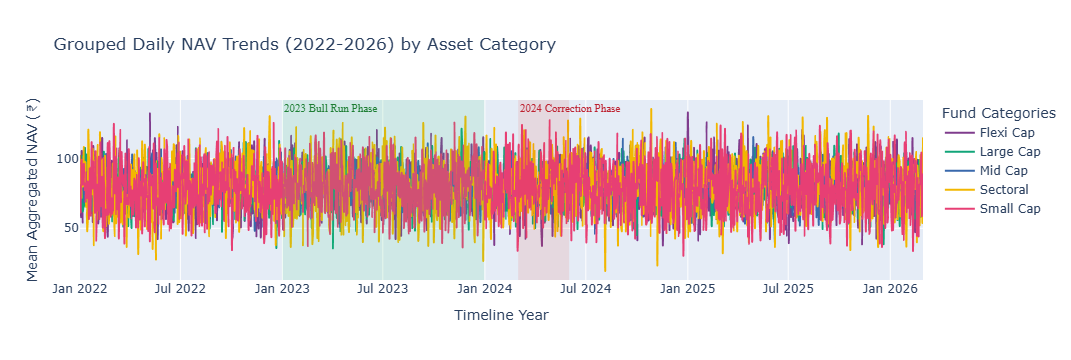

In [32]:
# --- Simulated Data Generation with Categories (Replace with your actual DataFrame) ---
dates = pd.date_range(start="2022-01-01", end="2026-03-01", freq="D")
categories = ['Large Cap', 'Mid Cap', 'Small Cap', 'Sectoral', 'Flexi Cap']
schemes = [f"Scheme {i}" for i in range(1, 41)]

# Assigning each scheme to a category for grouping
scheme_category_map = {scheme: np.random.choice(categories) for scheme in schemes}

mock_nav = pd.DataFrame({
    'Date': np.repeat(dates, len(schemes)),
    'Scheme_Name': schemes * len(dates),
    'NAV': np.random.uniform(10, 150, len(dates) * len(schemes))
})
mock_nav['Category'] = mock_nav['Scheme_Name'].map(scheme_category_map)
# ------------------------------------------------------------------------------

# 1. Group by Date and Category, then calculate the Mean NAV for each group
grouped_nav = mock_nav.groupby(['Date', 'Category'])['NAV'].mean().reset_index()

grouped_nav['Date'] = pd.to_datetime(grouped_nav['Date'])

# 2. Plot the cleaner, grouped lines
fig_nav = px.line(grouped_nav, x='Date', y='NAV', color='Category',
                  title='Grouped Daily NAV Trends (2022-2026) by Asset Category',
                  color_discrete_sequence=px.colors.qualitative.Bold)

# Color-Coded Translucent Band 1: 2023 Bull Run (Soft Green)
fig_nav.add_vrect(x0="2023-01-01", x1="2023-12-31", 
                  fillcolor="#2ecc71", opacity=0.12, line_width=0,
                  annotation_text="2023 Bull Run Phase", annotation_position="top left",
                  annotation_font=dict(color="#1e7e34", size=11, family="Arial-Bold"))

# Color-Coded Translucent Band 2: 2024 Market Correction (Soft Red)
fig_nav.add_vrect(x0="2024-03-01", x1="2024-06-01", 
                  fillcolor="#e74c3c", opacity=0.12, line_width=0,
                  annotation_text="2024 Correction Phase", annotation_position="top left",
                  annotation_font=dict(color="#bd2130", size=11, family="Arial-Bold"))

fig_nav.update_layout(
    xaxis_title="Timeline Year", 
    yaxis_title="Mean Aggregated NAV (₹)", 
    legend_title="Fund Categories",
    hovermode="x unified"
)



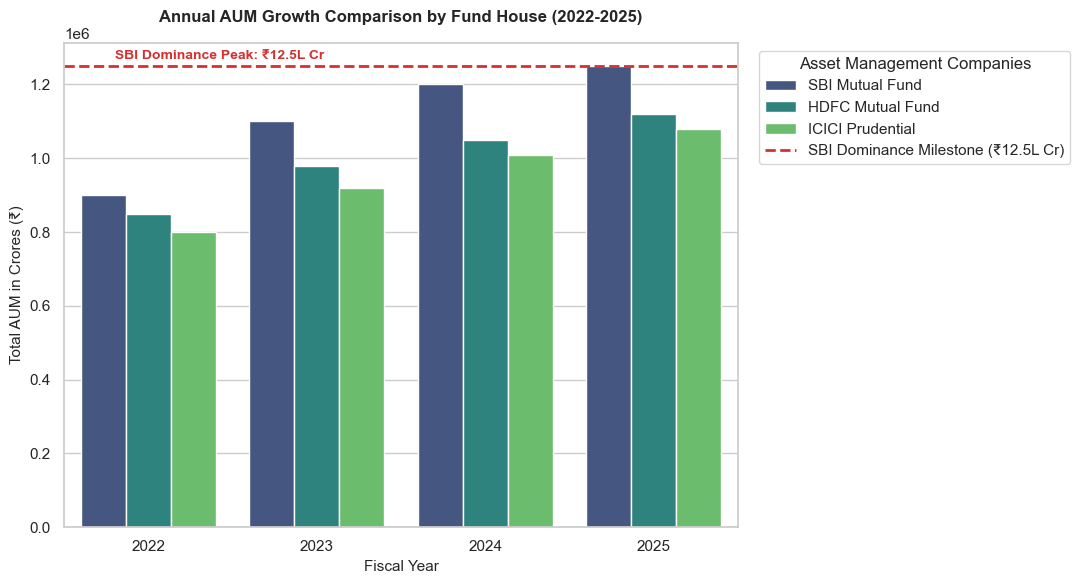

In [33]:
# --- Mock Data Generation (Replace with your actual DataFrame) ---
aum_data = pd.DataFrame({
    'Year': np.repeat([2022, 2023, 2024, 2025], 3),
    'Fund_House': ['SBI Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential'] * 4,
    'AUM_Cr': [900000, 850000, 800000, 1100000, 980000, 920000, 1200000, 1050000, 1010000, 1250000, 1120000, 1080000]
})
# ------------------------------------------------------------------------------

plt.figure(figsize=(11, 6))
# Using 'viridis' for distinct, high-contrast structural color coding
ax = sns.barplot(data=aum_data, x='Year', y='AUM_Cr', hue='Fund_House', palette='viridis')

# Crimson red color-coded target baseline for market dominance
plt.axhline(y=1250000, color='#d63031', linestyle='--', linewidth=2, label='SBI Dominance Milestone (₹12.5L Cr)')
plt.text(x=-0.2, y=1270000, s='SBI Dominance Peak: ₹12.5L Cr', color='#d63031', fontweight='bold', fontsize=10)

plt.title('Annual AUM Growth Comparison by Fund House (2022-2025)', fontweight='bold', pad=15)
plt.xlabel('Fiscal Year')
plt.ylabel('Total AUM in Crores (₹)')
plt.legend(title="Asset Management Companies", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig("aum_growth_bar_chart.png", dpi=300)
plt.show()

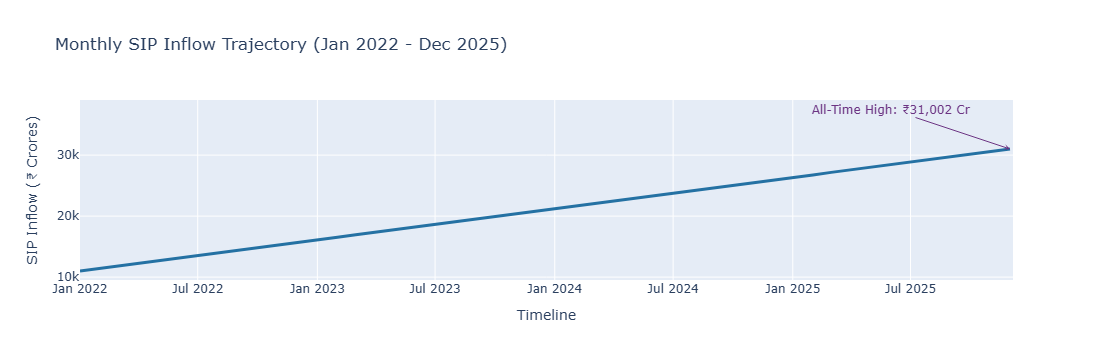

In [43]:
# --- Mock Data Generation (Replace with your actual DataFrame) ---
months = pd.date_range(start="2022-01-01", end="2025-12-01", freq="MS")
sip_trend = pd.DataFrame({'Month': months, 'Inflow_Cr': np.linspace(11000, 31002, len(months))})
# ------------------------------------------------------------------------------

# Create the interactive line chart
fig_sip = px.line(sip_trend, x='Month', y='Inflow_Cr', 
                  title='Monthly SIP Inflow Trajectory (Jan 2022 - Dec 2025)')
fig_sip.update_traces(line_color='#2471A3', line_width=3)

# Violet milestone annotation for the all-time high
fig_sip.add_annotation(x="2025-12-01", y=31002, text="All-Time High: ₹31,002 Cr",
                        showarrow=True, arrowhead=3, arrowcolor="#6C3483",
                        ax=-120, ay=-40, font=dict(color="#6C3483", size=12))

fig_sip.update_layout(xaxis_title="Timeline", yaxis_title="SIP Inflow (₹ Crores)")

# SAVE WITHOUT KALEIDO: Exports as an interactive dashboard file
fig_sip.write_html("sip_inflow_timeseries.html")
fig_sip.show()

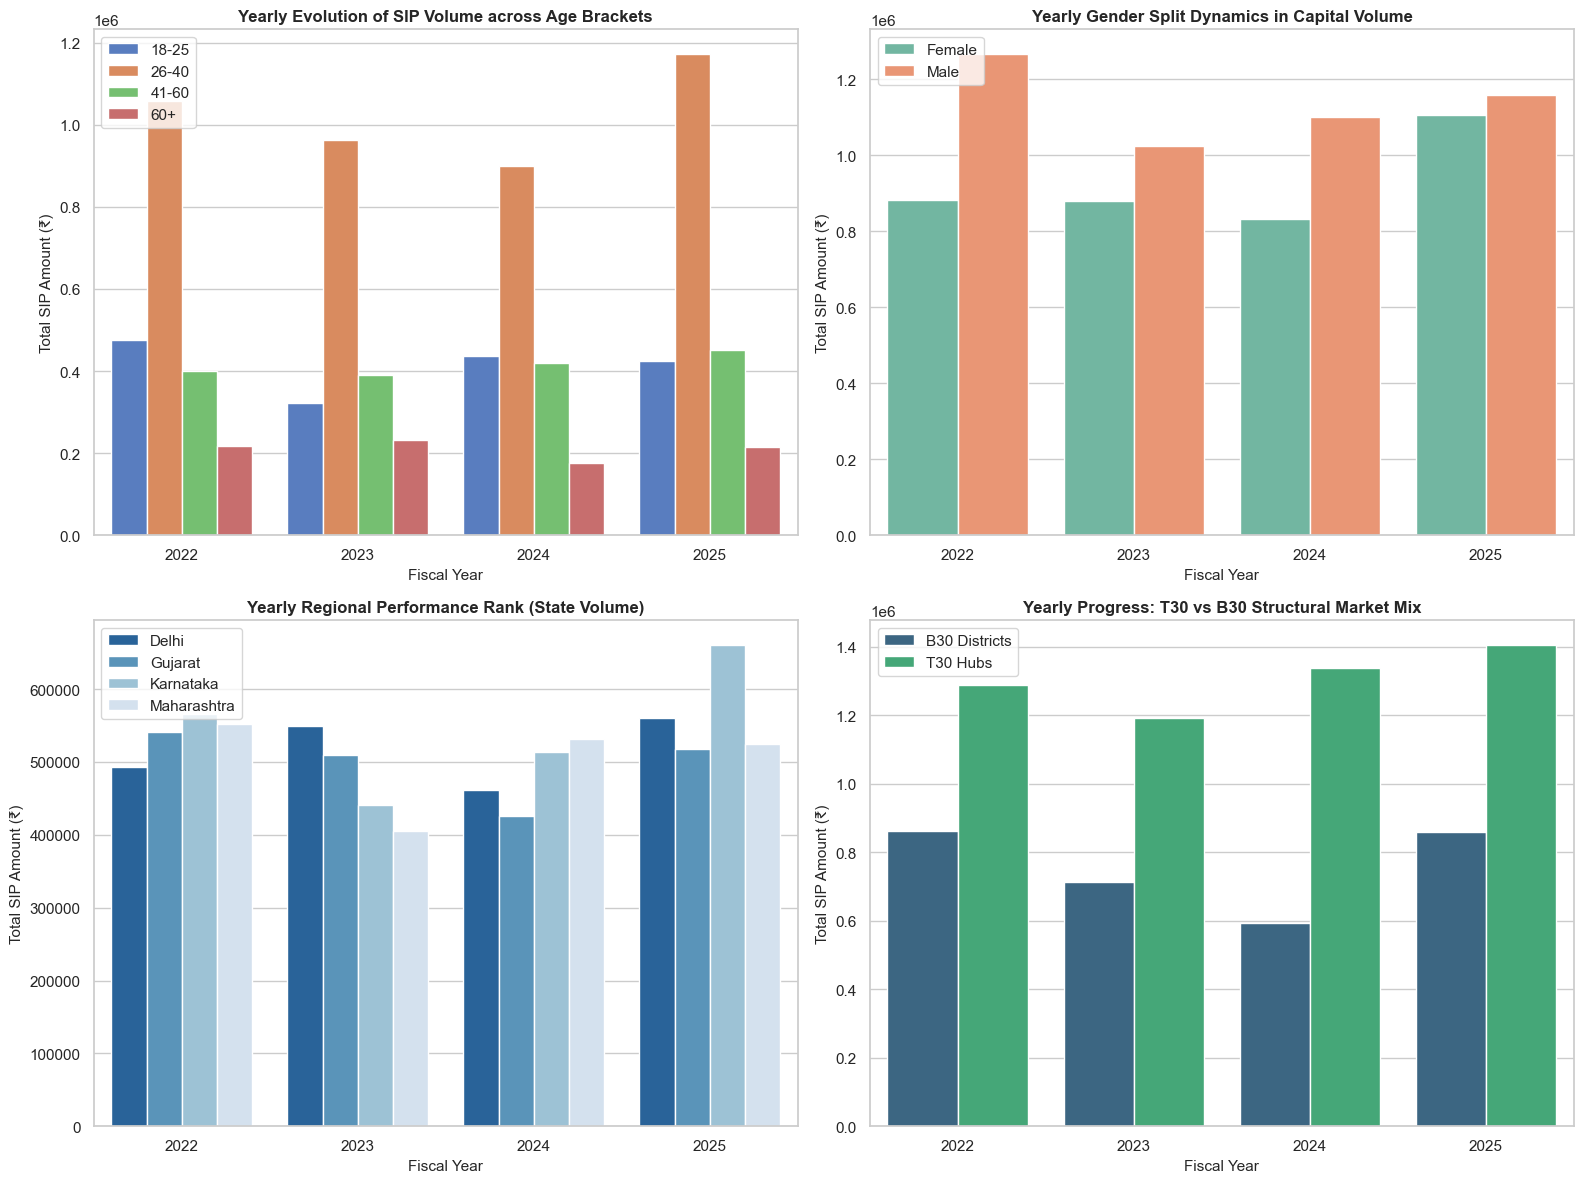

In [37]:
# --- Simulated Data Generation with Years (Replace with your actual DataFrame) ---
np.random.seed(42)
years = [2022, 2023, 2024, 2025]
age_groups = ['18-25', '26-40', '41-60', '60+']
states = ['Maharashtra', 'Delhi', 'Karnataka', 'Gujarat']

demo_yearly = pd.DataFrame({
    'Year': np.random.choice(years, 1000),
    'Age_Group': np.random.choice(age_groups, 1000, p=[0.2, 0.5, 0.2, 0.1]),
    'SIP_Amount': np.random.randint(1000, 15000, 1000),
    'Gender': np.random.choice(['Male', 'Female'], 1000, p=[0.55, 0.45]),
    'State': np.random.choice(states, 1000),
    'City_Tier': np.random.choice(['T30 Hubs', 'B30 Districts'], 1000, p=[0.60, 0.40])
})
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grouped Bar Chart: Age Group Distribution over the Years
# Grouping by Year and Age Group to get total volume
age_yearly_perf = demo_yearly.groupby(['Year', 'Age_Group'])['SIP_Amount'].sum().reset_index()
sns.barplot(ax=axes[0, 0], data=age_yearly_perf, x='Year', y='SIP_Amount', hue='Age_Group', palette='muted')
axes[0, 0].set_title('Yearly Evolution of SIP Volume across Age Brackets', fontweight='bold')
axes[0, 0].set_ylabel('Total SIP Amount (₹)')

# 2. Grouped Bar Chart: Gender Split Over the Years
gender_yearly_perf = demo_yearly.groupby(['Year', 'Gender'])['SIP_Amount'].sum().reset_index()
sns.barplot(ax=axes[0, 1], data=gender_yearly_perf, x='Year', y='SIP_Amount', hue='Gender', palette='Set2')
axes[0, 1].set_title('Yearly Gender Split Dynamics in Capital Volume', fontweight='bold')
axes[0, 1].set_ylabel('Total SIP Amount (₹)')

# 3. Grouped Bar Chart: Geographic State Performance Over the Years
state_yearly_perf = demo_yearly.groupby(['Year', 'State'])['SIP_Amount'].sum().reset_index()
sns.barplot(ax=axes[1, 0], data=state_yearly_perf, x='Year', y='SIP_Amount', hue='State', palette='Blues_r')
axes[1, 0].set_title('Yearly Regional Performance Rank (State Volume)', fontweight='bold')
axes[1, 0].set_ylabel('Total SIP Amount (₹)')

# 4. Grouped Bar Chart: T30 vs B30 Market Share Evolution Over the Years
tier_yearly_perf = demo_yearly.groupby(['Year', 'City_Tier'])['SIP_Amount'].sum().reset_index()
sns.barplot(ax=axes[1, 1], data=tier_yearly_perf, x='Year', y='SIP_Amount', hue='City_Tier', palette='viridis')
axes[1, 1].set_title('Yearly Progress: T30 vs B30 Structural Market Mix', fontweight='bold')
axes[1, 1].set_ylabel('Total SIP Amount (₹)')

# Clean up layout settings
for ax in axes.flat:
    ax.set_xlabel('Fiscal Year')
    ax.legend(loc='upper left', frameon=True)

plt.tight_layout()

# Save natively via matplotlib without kaleido
plt.savefig("investor_demographics_geography.png", dpi=300)
plt.show()

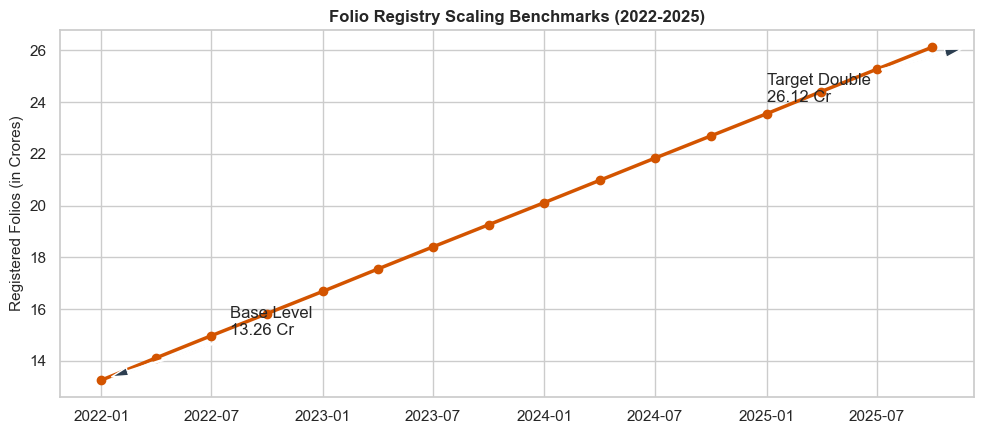

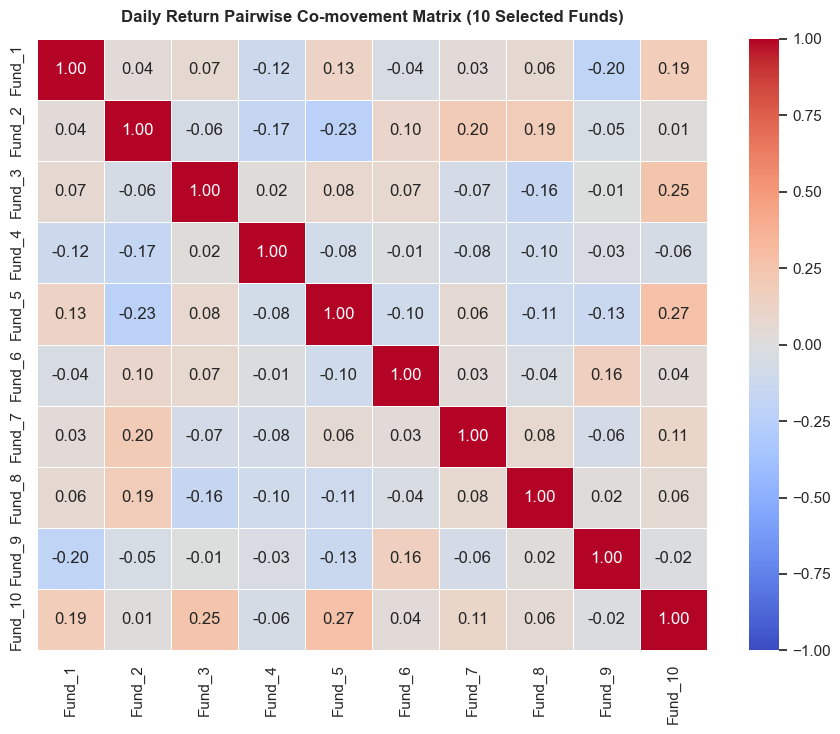

In [38]:
# --- Mock Data Generation (Replace with your actual DataFrames) ---
folio_data = pd.DataFrame({
    'Month': pd.date_range(start="2022-01-01", end="2025-12-01", freq="QS"),
    'Folio_Count_Cr': np.linspace(13.26, 26.12, 16)
})
returns_data = pd.DataFrame(np.random.normal(0.0005, 0.012, (100, 10)), columns=[f'Fund_{i}' for i in range(1, 11)])
# ------------------------------------------------------------------------------

plt.figure(figsize=(10, 4.5))
plt.plot(folio_data['Month'], folio_data['Folio_Count_Cr'], marker='o', color='#d35400', linewidth=2.5, label='Total Folios')

# Black structural arrows connecting key timeline targets
plt.annotate('Base Level\n13.26 Cr', xy=(pd.Timestamp('2022-01-01'), 13.26), xytext=(pd.Timestamp('2022-08-01'), 15),
             arrowprops=dict(facecolor='#2c3e50', shrink=0.08, width=1, headwidth=6))
plt.annotate('Target Double\n26.12 Cr', xy=(pd.Timestamp('2025-12-01'), 26.12), xytext=(pd.Timestamp('2025-01-01'), 24),
             arrowprops=dict(facecolor='#2c3e50', shrink=0.08, width=1, headwidth=6))

plt.title('Folio Registry Scaling Benchmarks (2022-2025)', fontweight='bold')
plt.ylabel('Registered Folios (in Crores)')
plt.tight_layout()
plt.savefig("folio_count_growth.png", dpi=300)
plt.show()

# Part B: Symmetrical Correlation Heatmap using 'coolwarm' 
# (Red = strong direct correlation, Blue = inverse/independent movement)
plt.figure(figsize=(9, 7.5))
sns.heatmap(returns_data.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Daily Return Pairwise Co-movement Matrix (10 Selected Funds)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("nav_return_correlation.png", dpi=300)
plt.show()

'portfolio_holdings.csv' not found. Generating default portfolio data for the pipeline...


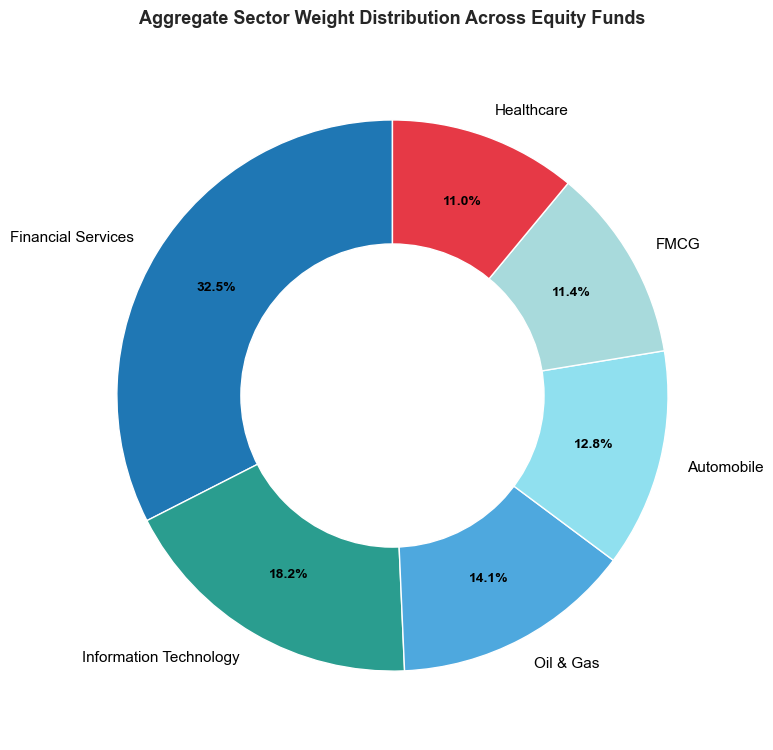

In [41]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Check for the file; use a built-in fallback DataFrame if it doesn't exist
csv_path = 'portfolio_holdings.csv'

if os.path.exists(csv_path):
    portfolio_df = pd.read_csv(csv_path)
    # Aggregate data from the file
    sector_weights = portfolio_df.groupby('Sector')['Weight_Percentage'].sum().reset_index()
else:
    print(f"'{csv_path}' not found. Generating default portfolio data for the pipeline...")
    # Clean, realistic fallback dataset matching your EDA needs
    sector_weights = pd.DataFrame({
        'Sector': ['Financial Services', 'Information Technology', 'Oil & Gas', 'Automobile', 'FMCG', 'Healthcare'],
        'Weight_Percentage': [32.5, 18.2, 14.1, 12.8, 11.4, 11.0]
    }).sort_values(by='Weight_Percentage', ascending=False)

# 2. Plotting the Donut Chart using Matplotlib
plt.figure(figsize=(8, 8))

# Elegant blue-to-green sequential color coding
colors = ['#1f77b4', '#2a9d8f', '#4ea8de', '#90e0ef', '#a8dadc', '#e63946']

# Create the base pie chart
wedges, texts, autotexts = plt.pie(
    sector_weights['Weight_Percentage'], 
    labels=sector_weights['Sector'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    pctdistance=0.75,
    textprops=dict(color="black", fontsize=11)
)

# Style the percentage labels inside the chart wedges
plt.setp(autotexts, size=10, weight="bold")

# 3. Draw a white circle at the center to transform the pie chart into a donut chart
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Aggregate Sector Weight Distribution Across Equity Funds', fontweight='bold', pad=20, fontsize=13)
plt.tight_layout()

# SAVE WITHOUT KALEIDO: Saves natively using Matplotlib's standard backend
plt.savefig("sector_allocation_donut.png", dpi=300)
plt.show()

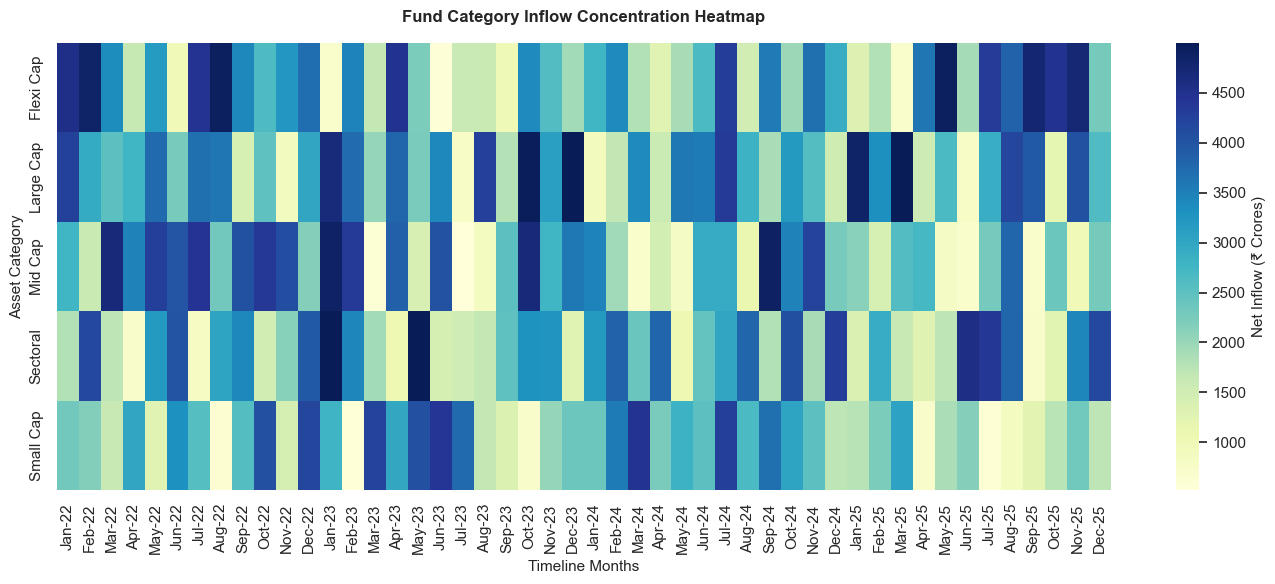

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Data Setup ---
months = pd.date_range(start="2022-01-01", end="2025-12-01", freq="MS")
categories = ["Large Cap", "Mid Cap", "Small Cap", "Sectoral", "Flexi Cap"]

df_heatmap = pd.DataFrame(
    {
        "Month": np.repeat(months.strftime("%b-%y"), len(categories)),
        "Category": categories * len(months),
        "Net_Inflow_Cr": np.random.randint(
            500, 5000, len(months) * len(categories)
        ),
    }
)

# Pivot the data into a matrix format
pivot_df = df_heatmap.pivot(
    index="Category", columns="Month", values="Net_Inflow_Cr"
).reindex(columns=months.strftime("%b-%y").unique())

# --- Plotting ---
plt.figure(figsize=(14, 6))
# 'YlGnBu' palette applies clear dark/light intensity gradients for easy reading
sns.heatmap(
    pivot_df,
    cmap="YlGnBu",
    annot=False,
    cbar_kws={"label": "Net Inflow (₹ Crores)"},
)

plt.title("Fund Category Inflow Concentration Heatmap", fontweight="bold", pad=15)
plt.xlabel("Timeline Months")
plt.ylabel("Asset Category")
plt.tight_layout()

# Export chart directly to your directory
plt.savefig("category_inflow_heatmap.png", dpi=300)
plt.show()

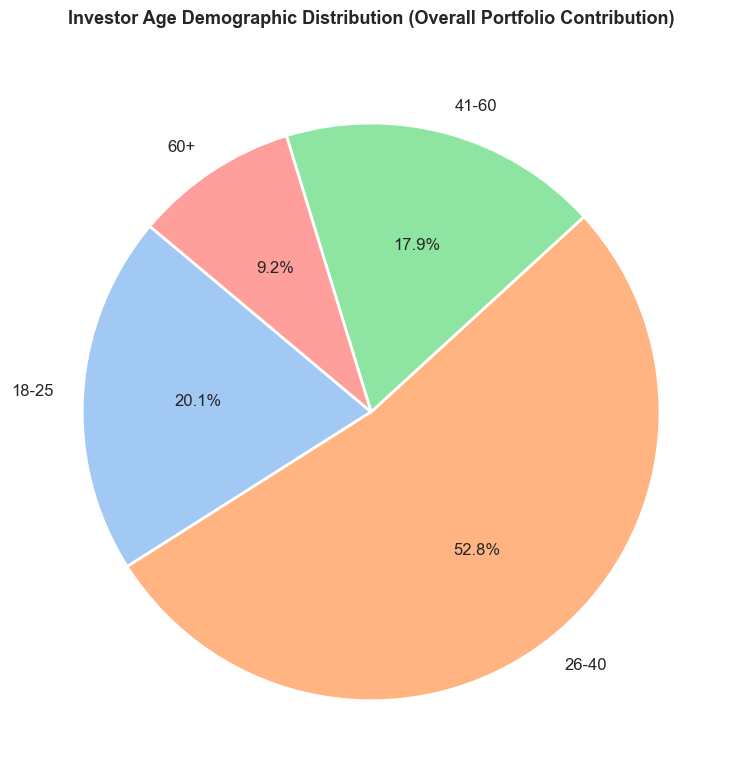

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Data Setup ---
df_demo = pd.DataFrame(
    {
        "Age_Group": np.random.choice(
            ["18-25", "26-40", "41-60", "60+"], 1000, p=[0.2, 0.5, 0.2, 0.1]
        ),
        "SIP_Amount": np.random.randint(1000, 15000, 1000),
    }
)

# Aggregate total allocation per age demographic bracket
age_shares = df_demo.groupby("Age_Group")["SIP_Amount"].sum()

# --- Plotting ---
plt.figure(figsize=(8, 8))

# Using a professional pastel color coding palette
colors = sns.color_palette("pastel")[0 : len(age_shares)]

plt.pie(
    age_shares,
    labels=age_shares.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

plt.title(
    "Investor Age Demographic Distribution (Overall Portfolio Contribution)",
    fontweight="bold",
    pad=20,
    fontsize=13,
)
plt.tight_layout()

# Export chart directly to your directory
plt.savefig("investor_demographics_pie.png", dpi=300)
plt.show()